<a href="https://colab.research.google.com/github/HimajaAmbati/todo/blob/main/Samplenih%20(aCNN%2CVIT1%2CVITResnet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# prompt: in the above code give me the correct paths

import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
from transformers import BertTokenizer
import urllib.request
import tarfile
import shutil
import glob
import random
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf # This should now work
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2

# Define constants
DATA_ROOT = "/con"  # Corrected data root directory
CSV_FILE = os.path.join(DATA_ROOT, "Data_Entry_2017.csv")  # Metadata file
BATCH_SIZE = 16
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import urllib.request

# URLs for the zip files
links = [
    'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz',
    'https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz',
    'https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz',
	'https://nihcc.box.com/shared/static/0aowwzs5lhjrceb3qp67ahp0rd1l1etg.gz',
    'https://nihcc.box.com/shared/static/v5e3goj22zr6h8tzualxfsqlqaygfbsn.gz',
	'https://nihcc.box.com/shared/static/asi7ikud9jwnkrnkj99jnpfkjdes7l6l.gz',
	'https://nihcc.box.com/shared/static/jn1b4mw4n6lnh74ovmcjb8y48h8xj07n.gz',
    'https://nihcc.box.com/shared/static/tvpxmn7qyrgl0w8wfh9kqfjskv6nmm1j.gz',
	'https://nihcc.box.com/shared/static/upyy3ml7qdumlgk2rfcvlb9k6gvqq2pj.gz',
	'https://nihcc.box.com/shared/static/l6nilvfa9cg3s28tqv1qc1olm3gnz54p.gz',
	'https://nihcc.box.com/shared/static/hhq8fkdgvcari67vfhs7ppg2w6ni4jze.gz',
	'https://nihcc.box.com/shared/static/ioqwiy20ihqwyr8pf4c24eazhh281pbu.gz'
]

for idx, link in enumerate(links):
    fn = 'images_%02d.tar.gz' % (idx+1)
    print('downloading'+fn+'...')
    urllib.request.urlretrieve(link, fn)  # download the zip file

print("Download complete. Please check the checksums")

downloadingimages_01.tar.gz...
downloadingimages_02.tar.gz...
downloadingimages_03.tar.gz...
downloadingimages_04.tar.gz...
downloadingimages_05.tar.gz...
downloadingimages_06.tar.gz...
downloadingimages_07.tar.gz...
downloadingimages_08.tar.gz...
downloadingimages_09.tar.gz...
downloadingimages_10.tar.gz...
downloadingimages_11.tar.gz...
downloadingimages_12.tar.gz...
Download complete. Please check the checksums


In [ ]:
# prompt: in this code the root directory is  /content/sample_data/nih so change code according to it
# import tarfile
# import os
# import shutil
# # Function to extract files from a tar.gz archive
# def extract_files(tar_file, extract_to):
#     with tarfile.open(tar_file, 'r:gz') as tar_ref:
#         tar_ref.extractall(extract_to)
# # Directory containing the downloaded files
# download_directory = '.'  # Assuming the script is in the same directory as the downloaded files
# # Create a new directory called "input"
# input_directory = os.path.join(download_directory, 'input')
# if not os.path.exists(input_directory):
#     os.makedirs(input_directory)
# # Loop through each downloaded file and extract its contents
# for idx in range(1, len(links) + 1):
#     tar_file = f'images_{idx:02d}.tar.gz'
#     extract_to = os.path.join(download_directory, f'images_{idx:02d}')
#     if not os.path.exists(extract_to):
#         os.makedirs(extract_to)
#     print(f'Extracting {tar_file} to {extract_to}...')
#     extract_files(tar_file, extract_to)
#     # Move extracted images to the "input" directory
#     for root, dirs, files in os.walk(extract_to):
#         for file in files:
#             sub_dir = os.path.join(input_directory, 'images')
#             # Create a new directory called "images"
#             if not os.path.exists(sub_dir):
#                 os.makedirs(sub_dir)
#             src_path = os.path.join(root, file)
#             dest_path = os.path.join(input_directory, file)
#             shutil.move(src_path, dest_path)
# print("Extraction complete.")

import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
from transformers import BertTokenizer
import urllib.request
import tarfile
import shutil
import glob
import random
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf # This should now work
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2


# Define constants
DATA_ROOT = "/content/sample_data/nih"  # Corrected data root directory
CSV_FILE = os.path.join(DATA_ROOT, "Data_Entry_2017.csv")  # Metadata file
BATCH_SIZE = 16
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# URLs for the zip files
links = [
    'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz',
    'https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz',
    'https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz',
	'https://nihcc.box.com/shared/static/0aowwzs5lhjrceb3qp67ahp0rd1l1etg.gz',
    'https://nihcc.box.com/shared/static/v5e3goj22zr6h8tzualxfsqlqaygfbsn.gz',
	'https://nihcc.box.com/shared/static/asi7ikud9jwnkrnkj99jnpfkjdes7l6l.gz',
	'https://nihcc.box.com/shared/static/jn1b4mw4n6lnh74ovmcjb8y48h8xj07n.gz',
    'https://nihcc.box.com/shared/static/tvpxmn7qyrgl0w8wfh9kqfjskv6nmm1j.gz',
	'https://nihcc.box.com/shared/static/upyy3ml7qdumlgk2rfcvlb9k6gvqq2pj.gz',
	'https://nihcc.box.com/shared/static/l6nilvfa9cg3s28tqv1qc1olm3gnz54p.gz',
	'https://nihcc.box.com/shared/static/hhq8fkdgvcari67vfhs7ppg2w6ni4jze.gz',
	'https://nihcc.box.com/shared/static/ioqwiy20ihqwyr8pf4c24eazhh281pbu.gz'
]

for idx, link in enumerate(links):
    fn = 'images_%02d.tar.gz' % (idx+1)
    print('downloading'+fn+'...')
    urllib.request.urlretrieve(link, os.path.join(DATA_ROOT, fn))  # download the zip file


# Function to extract files from a tar.gz archive
def extract_files(tar_file, extract_to):
    with tarfile.open(tar_file, 'r:gz') as tar_ref:
        tar_ref.extractall(extract_to)

# Create a new directory called "input" inside DATA_ROOT
input_directory = os.path.join(DATA_ROOT, 'input')
if not os.path.exists(input_directory):
    os.makedirs(input_directory)

# Loop through each downloaded file and extract its contents
for idx in range(1, len(links) + 1):
    tar_file = os.path.join(DATA_ROOT, f'images_{idx:02d}.tar.gz')
    extract_to = os.path.join(DATA_ROOT, f'images_{idx:02d}')
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    print(f'Extracting {tar_file} to {extract_to}...')
    extract_files(tar_file, extract_to)
    # Move extracted images to the "input" directory
    for root, dirs, files in os.walk(extract_to):
        for file in files:
            sub_dir = os.path.join(input_directory, 'images')
            # Create a new directory called "images"
            if not os.path.exists(sub_dir):
                os.makedirs(sub_dir)
            src_path = os.path.join(root, file)
            dest_path = os.path.join(sub_dir, file) # Corrected destination path
            shutil.move(src_path, dest_path)

print("Extraction complete.")


In [ ]:
DATA_ROOT = "/content/sample_data"  # Corrected data root directory
CSV_FILE = os.path.join(DATA_ROOT, "Data_Entry_2017.csv")  # Metadata file
BATCH_SIZE = 16
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Function to extract files from a tar.gz archive
def extract_files(tar_file, extract_to):
    with tarfile.open(tar_file, 'r:gz') as tar_ref:
        tar_ref.extractall(extract_to)

# Create a new directory called "input" inside DATA_ROOT
input_directory = os.path.join(DATA_ROOT, 'nih')
if not os.path.exists(input_directory):
    os.makedirs(input_directory)

# Loop through each downloaded file and extract its contents
for idx in range(1, len(links) + 1):
    tar_file = os.path.join(DATA_ROOT, f'images_{idx:02d}.tar.gz')
    extract_to = os.path.join(DATA_ROOT, f'images_{idx:02d}')
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    print(f'Extracting {tar_file} to {extract_to}...')
    extract_files(tar_file, extract_to)
    # Move extracted images to the "input" directory
    for root, dirs, files in os.walk(extract_to):
        for file in files:
            sub_dir = os.path.join(input_directory, 'images')
            # Create a new directory called "images"
            if not os.path.exists(sub_dir):
                os.makedirs(sub_dir)
            src_path = os.path.join(root, file)
            dest_path = os.path.join(sub_dir, file) # Corrected destination path
            shutil.move(src_path, dest_path)

print("Extraction complete.")

In [1]:
import glob
import os
import random
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import torch
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2

warnings.filterwarnings('ignore')

In [2]:
class DatasetParser():
    def __init__(self, root_dir, images_dir, labels_csv):
        self.image_paths = sorted(glob.glob(os.path.join(root_dir, images_dir,"*.png")))
        self.labels_df = self._labels_by_task(root_dir=root_dir, labels_csv=labels_csv)

        self.labels = ['Cardiomegaly','Emphysema','Effusion',
                           'Hernia','Nodule','Pneumothorax','Atelectasis',
                           'Pleural_Thickening','Mass','Edema','Consolidation',
                           'Infiltration','Fibrosis','Pneumonia', 'No Finding']

    def visualize_random_images(self, num_images=1, label=None, display_label=False):
        fig = plt.figure(figsize=(20,20))
        fig.tight_layout(pad=10.0)
        if label is None:
            idxs = random.sample(range(len(self.image_paths)), num_images)
        else:
            idxs = [idx for idx in range(len(self.labels_df['Label'])) if label in self.labels_df['Label'][idx]]
            if len(idxs) < num_images:
                num_images = len(idxs)
            else:
                idxs = random
                (idxs, num_images)

        num_rows = math.ceil(np.sqrt(num_images))
        num_cols = math.ceil(num_images/num_rows)

        for i in range(num_images):
            img = cv2.imread(self.image_paths[idxs[i]])
            plt.subplot(num_rows, num_cols, i+1)
            if display_label:
                plt.gca().set_title(self.labels_df['Label'][idxs[i]],wrap=True)
            plt.axis('off')
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    def _labels_by_task(self, root_dir=None, labels_csv=None):

        labels_df = pd.read_csv(os.path.join(root_dir, labels_csv))
        image_path = {os.path.basename(x): x for x in glob.glob(os.path.join(root_dir, 'images', '*.png'))}

        labels_df = labels_df[labels_df['Image Index'].map(os.path.basename).isin(image_path)]

        new_labels_df = pd.DataFrame()
        new_labels_df['Id'] = labels_df['Image Index'].copy()

        new_labels_df['Label'] = labels_df['Finding Labels'].apply(lambda val: val.split('|'))

        del labels_df

        return new_labels_df

    def get_labels_df(self):
        new_labels_df = self.labels_df.copy()

        for i in range(len(new_labels_df)):
                one_hot = [0 for element in self.labels]
                for element in new_labels_df['Label'][i]:
                    one_hot[self.labels.index(element)] = 1
                new_labels_df['Label'][i] = one_hot

        return new_labels_df

    def sample(self, num_samples, is_weighted=False):
        if not is_weighted:
            return self.labels_df.sample(num_samples)
        else:
            sample_weights = self.labels_df['Label'].map(lambda x: len(x)).values + 4e-2
            sample_weights /= sample_weights.sum()
            return self.labels_df.sample(num_samples, weights=sample_weights)

In [35]:
parser = DatasetParser(root_dir="/content/sample_data",
                       images_dir="images",
                       labels_csv="sample_labels.csv")
print("Total Trainable Data: ", parser.labels_df.shape[0])

Total Trainable Data:  4168


In [36]:
df = parser.sample(100, is_weighted=True)
df.head()

,Id,Label
2227,00011454_003.png,[Pneumothorax]
251,00001347_002.png,[No Finding]
3763,00018451_006.png,"[Cardiomegaly, Effusion]"
1852,00009759_002.png,"[Atelectasis, Effusion, Hernia]"
5018,00026573_005.png,[Mass]


In [37]:
train_val, test = train_test_split(df, test_size=0.2, random_state=42)  # Split into train+val (80%) and test (20%)
train, val = train_test_split(train_val, test_size=0.25, random_state=42)  # Split remaining data into train (60%) and val (20%)

train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)

print("Training set size: ", len(train))
print("Validation set size: ", len(val))
print("Test set size: ", len(test))

Training set size:  60
Validation set size:  20
Test set size:  20


In [39]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   horizontal_flip = True,
                                   vertical_flip = False,
                                   height_shift_range= 0.05,
                                   width_shift_range=0.1,
                                   rotation_range=5,
                                   shear_range = 0.1,
                                   fill_mode = 'reflect',
                                   zoom_range=0.15)

val_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_dataframe(
        dataframe=train,
        directory='/content/sample_data/images',
        x_col="Id",
        y_col="Label",
        batch_size=32,
        target_size=(224,224),
        classes = parser.labels)

validation_generator = val_datagen.flow_from_dataframe(
        dataframe=val,
        directory='/content/sample_data/images',
        x_col="Id",
        y_col="Label",
        batch_size=32,
        target_size=(224,224),
        classes = parser.labels)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test,
    directory='/content/sample_data/images',
    x_col="Id",
    y_col="Label",
    class_mode = "categorical",
    batch_size=32,
    target_size=(224, 224),
    classes = parser.labels,
    shuffle = False)

Found 60 validated image filenames belonging to 15 classes.
Found 20 validated image filenames belonging to 15 classes.
Found 20 validated image filenames belonging to 15 classes.


CNN

In [40]:
batch_size = 32
learning_rate = 1e-4
weight_decay = 1e-6
num_epochs = 10
num_classes = 15

In [47]:
!pip install tensorflow

In [54]:
import glob
import os
import random
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import torch
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer


from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2

In [59]:
def create_cnn_classifier():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', name="last_conv_layer"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(512, activation='relu'),
        Dense(num_classes, activation='sigmoid')
    ])
    return model

In [60]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )
    model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
    ]
    )
    history = model.fit(
        train_generator,
        epochs=num_epochs,
        validation_data=validation_generator,
        callbacks=[ModelCheckpoint(os.path.join("files", "model.keras"), monitor='val_loss', verbose=1, save_best_only=True)]
    )

    return history

In [61]:
cnn_classifier = create_cnn_classifier()
history_cnn = run_experiment(cnn_classifier)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6954 - auc: 0.5144 - loss: 0.5851
Epoch 1: val_loss improved from inf to 0.28063, saving model to files/model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 28s 20s/step - accuracy: 0.7177 - auc: 0.5398 - loss: 0.5530 - val_accuracy: 0.9033 - val_auc: 0.7786 - val_loss: 0.2806
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.8994 - auc: 0.7990 - loss: 0.2884
Epoch 2: val_loss did not improve from 0.28063
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8999 - auc: 0.7963 - loss: 0.2875 - val_accuracy: 0.8967 - val_auc: 0.8089 - val_loss: 0.2905
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9153 - auc: 0.8168 - loss: 0.2803
Epoch 3: val_loss did not improve from 0.28063
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9120 - auc: 0.8187 - loss: 0.2824 - val_accuracy: 0.9033 - val_auc: 0.7928 - val_loss: 0.3003
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8957 - auc: 0.8003 - loss: 0.3159   
Epoc

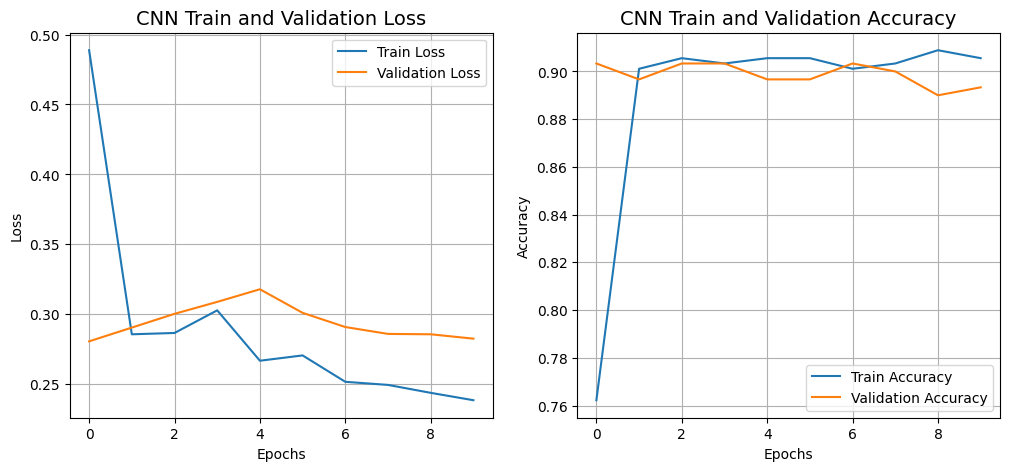

In [63]:
def plot_combined_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('CNN Train and Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('CNN Train and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    plt.show()
plot_combined_history(history_cnn)

VIT 1


In [64]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = Dense(units, activation=tf.nn.gelu)(x)
        x = Dropout(dropout_rate)(x)
    return x

In [65]:
from tensorflow.keras import layers

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super(Patches, self).get_config()
        config.update({"patch_size": self.patch_size})
        return config

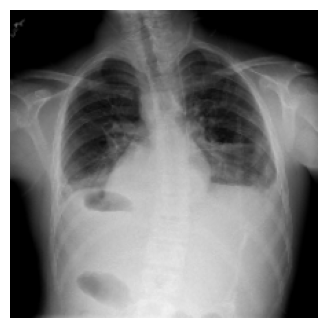

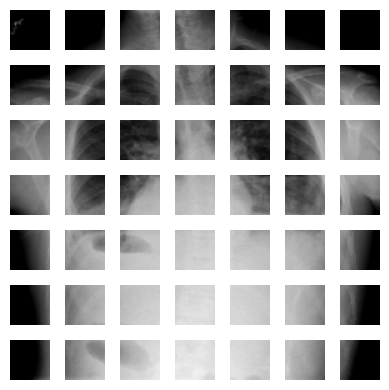

In [67]:
for image_batch, label_batch in train_generator:
    image = image_batch[0]
    break

image_size = 224
patch_size = 32
num_patches = (image_size // patch_size) ** 2

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

image_tensor = tf.expand_dims(image, 0)

patches_layer = Patches(patch_size)
patches = patches_layer(image_tensor)

patches_numpy = patches.numpy()
if np.max(patches_numpy) <= 1.0:
    patches_numpy *= 255
patches_numpy = patches_numpy.astype('uint8')

n = int(np.sqrt(num_patches))
plt.figure(figsize=(4, 4))
for i in range(n * n):
    ax = plt.subplot(n, n, i + 1)
    patch_img = patches_numpy[0, i].reshape(patch_size, patch_size, 3)
    plt.imshow(patch_img)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [68]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

In [70]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.expand_dims(
            tf.range(start=0, limit=self.num_patches, delta=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

In [86]:
def create_vit_classifier():
    input_shape = (224, 224, 3)
    inputs = Input(shape=input_shape)

    # Define necessary hyperparameters
    projection_dim = 64
    transformer_layers = 8  # Define the number of transformer layers
    num_heads = 4
    transformer_units = [
        projection_dim * 2,
        projection_dim,
    ]
    mlp_head_units = [2048, 1024]

    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = Add()([attention_output, encoded_patches])
        x3 = LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        encoded_patches = Add()([x3, x2])

    representation = LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = Flatten()(representation)
    representation = Dropout(0.5)(representation)
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    logits = Dense(num_classes, activation='sigmoid')(features)

    model = Model(inputs=inputs, outputs=logits)
    return model

In [87]:
batch_size = 32
learning_rate = 1e-4
weight_decay = 1e-6
num_epochs = 10

In [88]:
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, Add, MultiHeadAttention, Flatten
from tensorflow.keras import layers, models, Model, ops

In [89]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )
    model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
    ]
    )

    history = model.fit(
        train_generator,
        epochs=num_epochs,
        validation_data=validation_generator,
    )

    return history

In [90]:
vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 84s 30s/step - accuracy: 0.6014 - auc: 0.5302 - loss: 0.8475 - val_accuracy: 0.8967 - val_auc: 0.7936 - val_loss: 0.2748
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8147 - auc: 0.6021 - loss: 0.5258 - val_accuracy: 0.8967 - val_auc: 0.7983 - val_loss: 0.2672
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 976ms/step - accuracy: 0.8545 - auc: 0.6142 - loss: 0.4371 - val_accuracy: 0.9033 - val_auc: 0.8062 - val_loss: 0.2937
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8670 - auc: 0.7417 - loss: 0.3880 - val_accuracy: 0.9000 - val_auc: 0.8034 - val_loss: 0.3023
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8856 - auc: 0.7054 - loss: 0.3980 - val_accuracy: 0.8967 - val_auc: 0.8124 - val_loss: 0.3019
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8871 - auc: 0.7650 - loss: 0.3547 - val_accuracy: 0.8967 - val_auc: 0.8103 - val_loss: 0.2952
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.877

In [91]:
def plot_combined_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Train and Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Train and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    # plt.savefig('combined_historyV1.png')
    plt.show()

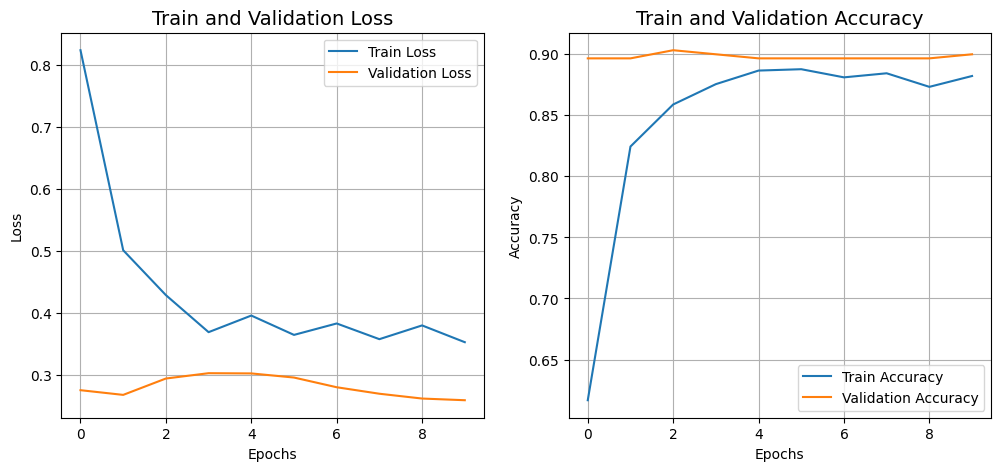

In [92]:
plot_combined_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
Test accuracy: 90.33%
Test AUC: 0.72
Test loss: 0.29
Shape of y_true: (20, 15)
Shape of predictions: (20, 15)


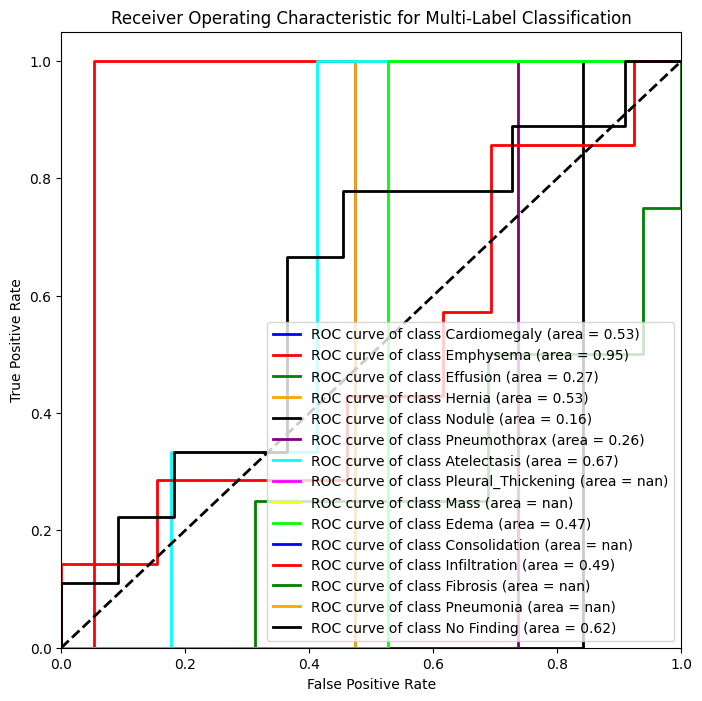

In [94]:
from itertools import cycle
from sklearn.metrics import roc_curve, auc
test_generator.reset()
steps = int(np.ceil(len(test_generator.filenames) / test_generator.batch_size))
predictions = vit_classifier.predict(test_generator, steps=steps, verbose=1)

loss, test_accuracy, test_auc = vit_classifier.evaluate(test_generator, steps=len(test_generator), verbose=0)

print("Test accuracy: {:.2f}%".format(test_accuracy * 100))
print("Test AUC: {:.2f}".format(test_auc))
print("Test loss: {:.2f}".format(loss))

def plot_roc_curves(y_true, y_pred, num_classes, class_labels):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 8))
    colors = cycle(['blue', 'red', 'green', 'orange', 'black', 'purple', 'cyan', 'magenta', 'yellow', 'lime'])
    for i, color in zip(range(num_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for Multi-Label Classification')
    plt.legend(loc="lower right")
    # plt.savefig("roc_curve.png")
    plt.show()

mlb = MultiLabelBinarizer(classes=parser.labels)
y_true = mlb.fit_transform(val['Label'])
if y_true.shape[0] > predictions.shape[0]:
    y_true = y_true[:predictions.shape[0], :]

print("Shape of y_true:", y_true.shape)
print("Shape of predictions:", predictions.shape)

plot_roc_curves(y_true, predictions, num_classes=len(parser.labels), class_labels=parser.labels)

ViT-Resnet

In [95]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import timm

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [96]:
class ChestXRayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label
data_path = "/content/sample_data"
images_dir = "images"
labels_csv = "sample_labels.csv"

In [97]:
labels_df = pd.read_csv(os.path.join(data_path, labels_csv))

image_path = {os.path.basename(x): x for x in glob.glob(os.path.join(data_path, images_dir, '*.png'))}

labels_df = labels_df[labels_df['Image Index'].map(os.path.basename).isin(image_path)]

print('Total Images:', len(image_path), ', Total Input Rows:', labels_df.shape[0])

new_labels_df = pd.DataFrame()
new_labels_df['Id'] = labels_df['Image Index'].copy()
new_labels_df['labels'] = labels_df['Finding Labels'].apply(lambda val: val.split('|'))

mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(new_labels_df['labels'])
labels = np.array(labels, dtype=float)

image_paths = [image_path[os.path.basename(x)] for x in new_labels_df['Id']]

Total Images: 4168 , Total Input Rows: 4168


In [98]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [99]:
train_paths, val_test_paths, train_labels, val_test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    val_test_paths, val_test_labels, test_size=0.5, random_state=42)

train_dataset = ChestXRayDataset(train_paths, train_labels, transform)
val_dataset = ChestXRayDataset(val_paths, val_labels, transform)
test_dataset = ChestXRayDataset(test_paths, test_labels, transform)

batch_size = 16
loader_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loader_test = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device, f"({torch.cuda.get_device_name(device)})" if torch.cuda.is_available() else "")

Using device:  cuda (Tesla T4)


In [101]:
model = timm.create_model('vit_base_patch16_224', pretrained=True)
num_classes = 15
model.head = nn.Linear(model.head.in_features, num_classes)
model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [102]:
def train_model(model, criterion, optimizer, loader_train, loader_val, num_epochs=10):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for inputs, labels in loader_train:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = outputs.sigmoid() > 0.5

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += (preds == labels.byte()).sum().item()
            total_samples += labels.numel()

        epoch_loss = running_loss / len(loader_train.dataset)
        epoch_acc = running_corrects / total_samples * 100
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%')

        val_loss, val_acc = validate_model(model, loader_val, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

    return train_losses, val_losses, train_accuracies, val_accuracies

In [103]:
def validate_model(model, loader_val, criterion, threshold=0.5):
    model.eval()
    total_samples = 0
    total_correct = 0
    running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in loader_val:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            predicted = outputs.sigmoid() > threshold

            running_loss += loss.item() * inputs.size(0)
            total_correct += (predicted == labels.byte()).sum().item()
            total_samples += labels.numel()

    val_loss = running_loss / len(loader_val.dataset)
    accuracy = total_correct / total_samples * 100
    print(f'Validation Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%')
    return val_loss, accuracy

In [104]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, criterion, optimizer, loader_train, loader_val, num_epochs=10)

Epoch 1/10, Train Loss: 0.2222, Train Acc: 92.17%
Validation Loss: 0.2025, Accuracy: 92.71%
Epoch 2/10, Train Loss: 0.2107, Train Acc: 92.68%
Validation Loss: 0.2054, Accuracy: 92.01%
Epoch 3/10, Train Loss: 0.2078, Train Acc: 92.88%
Validation Loss: 0.1948, Accuracy: 93.30%
Epoch 4/10, Train Loss: 0.2057, Train Acc: 92.95%
Validation Loss: 0.1931, Accuracy: 93.38%
Epoch 5/10, Train Loss: 0.2048, Train Acc: 93.01%
Validation Loss: 0.1902, Accuracy: 93.40%
Epoch 6/10, Train Loss: 0.2031, Train Acc: 92.99%
Validation Loss: 0.1909, Accuracy: 93.25%
Epoch 7/10, Train Loss: 0.2014, Train Acc: 93.01%
Validation Loss: 0.1916, Accuracy: 93.40%
Epoch 8/10, Train Loss: 0.1982, Train Acc: 93.08%
Validation Loss: 0.1969, Accuracy: 93.14%
Epoch 9/10, Train Loss: 0.2001, Train Acc: 93.06%
Validation Loss: 0.1945, Accuracy: 93.41%
Epoch 10/10, Train Loss: 0.1981, Train Acc: 93.09%
Validation Loss: 0.1896, Accuracy: 93.67%


In [ ]:
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy Over Epochs')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.savefig('training_and_validation_metrics.png')
plt.show()